# Top N Bit Importances
Ranked fingerprint bits by model importance.


In [5]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

MODEL_DIR = 'random-forest'
MODEL_NAME = 'Random Forest'

cwd = Path.cwd()
project_root = Path("..").resolve() if cwd.name == MODEL_DIR else cwd
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from qspr_config import (
    DATA_PATH,
    ECFP_RADIUS,
    ECFP_N_BITS,
    N_ESTIMATORS,
    N_ESTIMATORS_GRID,
    TOP_N_BITS,
    RANDOM_SEED,
    TEST_SIZE,
    CV_FOLDS,
    N_JOBS,
    FIG_DPI,
    FIGSIZE_SQUARE,
    FIGSIZE_SQUARE,
)
from qspr_common import (
    load_dataset,
    build_feature_matrix,
    make_binary_target,
    apply_plot_style,
    resolve_output_dir,
)

apply_plot_style()
out_dir = resolve_output_dir(MODEL_DIR)


In [6]:
df = load_dataset(DATA_PATH)
df, X = build_feature_matrix(df, radius=ECFP_RADIUS, n_bits=ECFP_N_BITS)


[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not removing hydrogen atom without neighbors
[11:29:29] WARNING: not r

In [7]:
y, cutoff = make_binary_target(df["Solubility"].to_numpy())


Saved: /Users/michael/dev/delta/qspr-explainability/qspr/random-forest/outputs/bit_importance_top_n.png


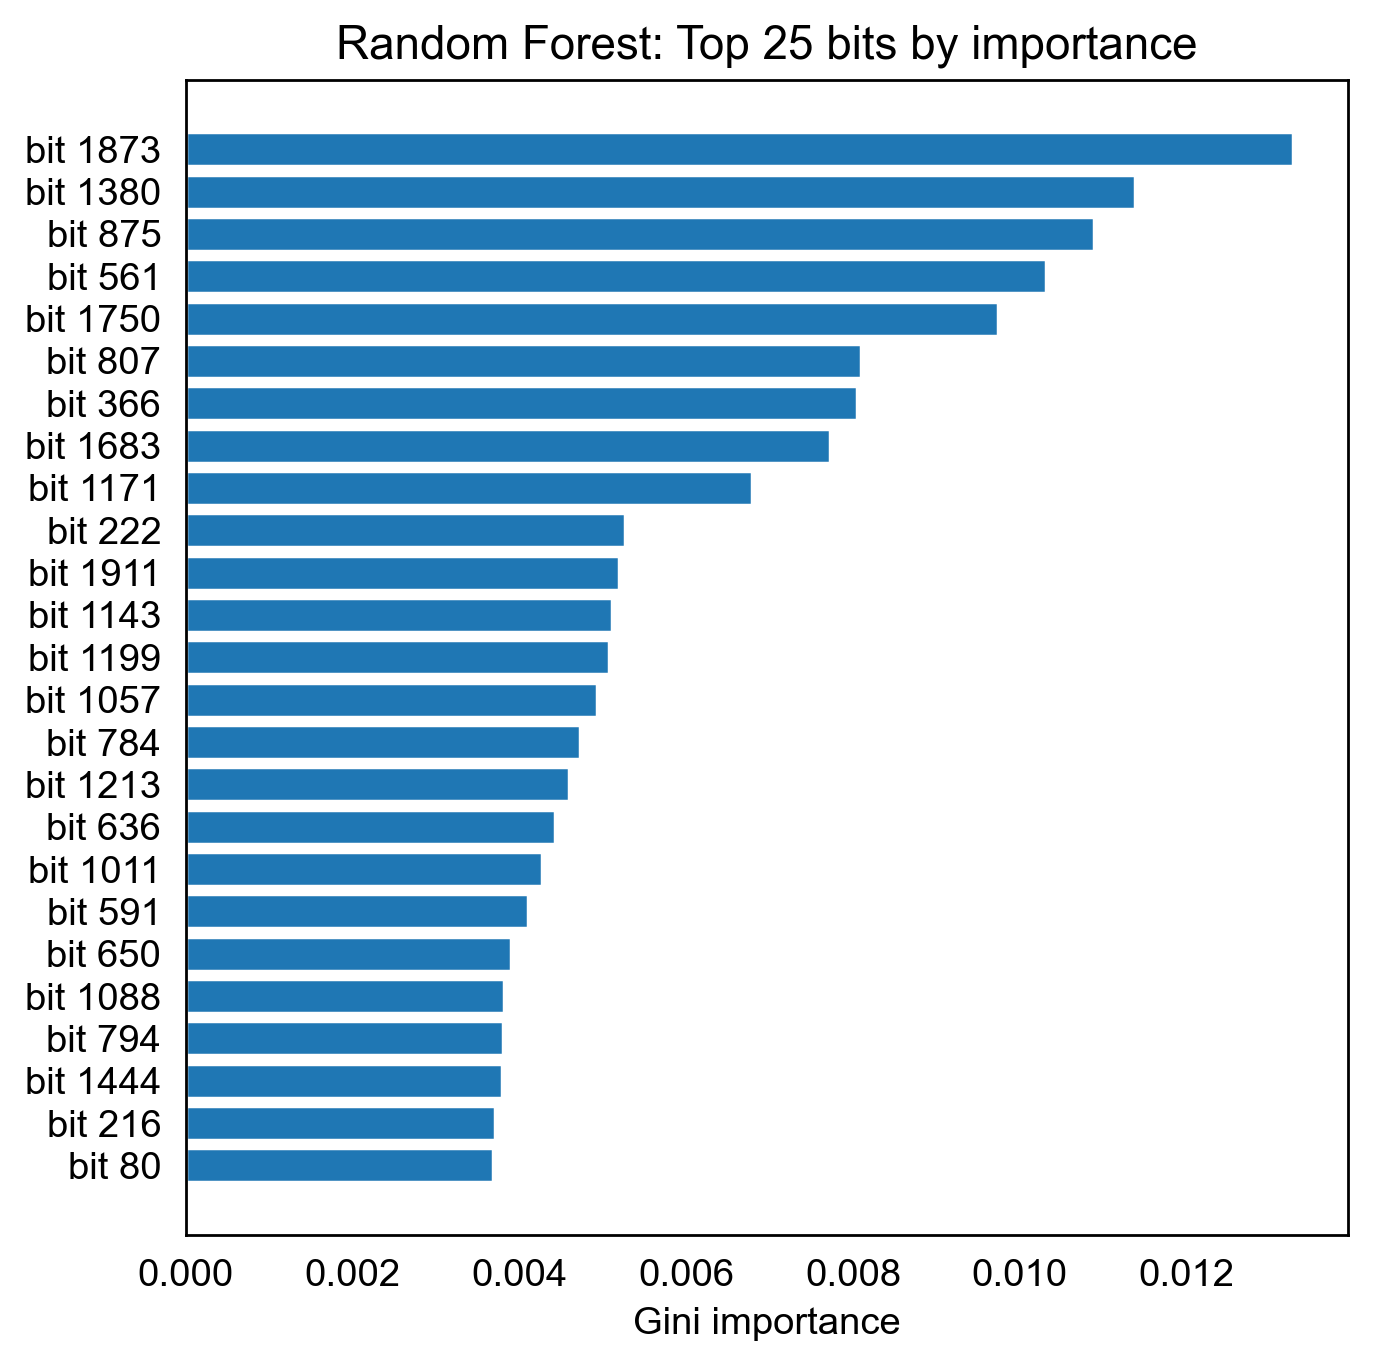

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=None,
    n_jobs=N_JOBS,
    random_state=RANDOM_SEED,
    class_weight='balanced_subsample'
)
rf.fit(X, y)

importances = rf.feature_importances_

order = np.argsort(importances)[::-1][:TOP_N_BITS]
top_imps = importances[order]

fig, ax = plt.subplots(figsize=FIGSIZE_SQUARE)
ax.barh(range(TOP_N_BITS), top_imps[::-1])
ax.set_yticks(range(TOP_N_BITS))
ax.set_yticklabels([f"bit {idx}" for idx in order[::-1]])
ax.set_xlabel("Gini importance")
ax.set_title(f"{MODEL_NAME}: Top {TOP_N_BITS} bits by importance")

out_path = out_dir / "bit_importance_top_n.png"
fig.savefig(out_path, dpi=FIG_DPI, bbox_inches="tight")
print(f"Saved: {out_path}")
